In [ ]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!{sys.executable} -m pip install scikit-learn optuna matplotlib seaborn

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optimizer
from torch.utils.data import Dataset  , DataLoader , random_split
from torchvision import datasets  , transforms
import optuna


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix , classification_report

# Loading the Fashion MNINST

In [7]:
data = datasets.FashionMNIST(root='data' , train=True , download=True , transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root='data' , train=False , download=True , transform=transforms.ToTensor())

train_size = int(0.8 * len(data))
val_size = len(data) - train_size
train_data , val_data = random_split(data , [train_size , val_size])

In [13]:
print(data.classes)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


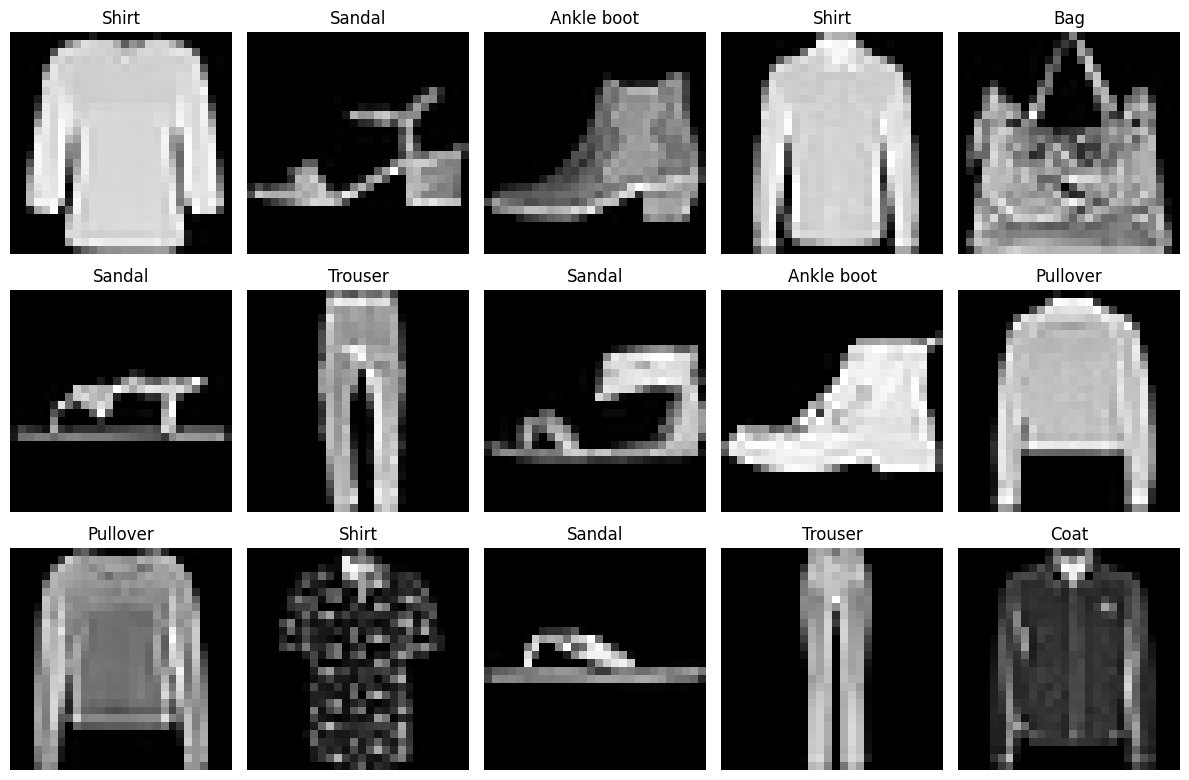

In [15]:
classes = data.classes
labels_map = dict()
for i , label in enumerate(classes):
    labels_map[i] = label


def visualize_samples(dataset, num_samples=15):
    plt.figure(figsize=(12, 8))

    for i in range(num_samples):
        idx = torch.randint(len(dataset), size=(1,)).item()
        image, label = dataset[idx]

        plt.subplot(3, 5, i + 1)
        plt.title(labels_map[label])
        plt.axis("off")

        plt.imshow(image.squeeze(), cmap="gray")

    plt.tight_layout()
    plt.show()

visualize_samples(train_data)

In [16]:
train_data.indices[:10]

[31456, 31802, 27806, 54610, 57167, 4135, 53634, 16046, 3193, 4928]

In [17]:
# Select only those rows that are selected for train
train_images = data.data[train_data.indices].reshape((train_size,784))
train_labels = nn.functional.one_hot(data.targets[train_data.indices] , num_classes=10).float()
val_images = data.data[val_data.indices].reshape((val_size,784))
val_labels = nn.functional.one_hot(data.targets[val_data.indices] , num_classes=10).float()
test_images = test_data.data.reshape((10000,784))
test_labels = nn.functional.one_hot(test_data.targets , num_classes=10).float()

In [18]:
print("Train Data")
print(train_images.shape)
print(train_labels.shape)
print("Train Data")
print(val_images.shape)
print(val_labels.shape)
print("Test Data")
print(test_images.shape)
print(test_labels.shape)

Train Data
torch.Size([48000, 784])
torch.Size([48000, 10])
Train Data
torch.Size([12000, 784])
torch.Size([12000, 10])
Test Data
torch.Size([10000, 784])
torch.Size([10000, 10])


# Creating the Custom Dataset class

In [19]:
class FashionMNISTDataset(Dataset):
    def __init__(self, images , labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return self.images.shape[0]
    def  __getitem__(self,index):
        return self.images[index] / 255 , self.labels[index]


In [20]:
train_dataset = FashionMNISTDataset(train_images , train_labels)
val_dataset = FashionMNISTDataset(val_images , val_labels)
test_dataset = FashionMNISTDataset(test_images , test_labels)

# Main Section

# ANN

In [21]:
class ANN(nn.Module):
    def __init__(self, input_dim , out_dim , hidden_layer_num , hidden_number_neuron , dropout_rate):
        super().__init__()
        curr_input_layer = input_dim

        layers = []
        for i in range(hidden_layer_num):
            layers.append(nn.Linear(curr_input_layer , hidden_number_neuron))
            layers.append(nn.BatchNorm1d(hidden_number_neuron))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            curr_input_layer = hidden_number_neuron
            hidden_number_neuron //= 2

            if hidden_number_neuron < 10:
                break


        layers.append(nn.Linear(curr_input_layer , out_dim))
        self.out = nn.Sequential(*layers)

    def forward(self,x):
        out = self.out(x)
        return out


In [22]:
print(torch.cuda.is_available())

True


In [26]:
def train(epoch , model  , optim, train_batches, val_batches, device , show=False):
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3)
    loss_fn = nn.CrossEntropyLoss()
    val_losses = []
    train_losses = []
    overall_loss_defference_sum = 0
    overall_acc_defference_sum = 0
    for i in range(epoch):
        model.train()
        # pbar  = tqdm(train_batches , desc=f"Training epoch{i+1} / {epoch} " , leave=False)
        train_loss_epoch = 0
        train_acc_epoch = 0
        for images , labels in train_batches:
            images = images.to(device)
            labels = labels.to(device)

            out = model(images)
            loss = loss_fn(out , labels)

            acc = (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
            train_acc_epoch += acc.item()

            train_loss_epoch += loss.item()
            optim.zero_grad()
            loss.backward()
            optim.step()
            # pbar.set_postfix({'loss':loss.item()})
        model.eval()
        val_loss_epoch = 0
        val_acc_epoch = 0
        with torch.no_grad():
            # val_pbar = tqdm(val_batches , desc=f"Validation epoch{i+1} / {epoch} " , leave=False)
            for val_images , val_labels in val_batches:
                val_images = val_images.to(device)
                val_labels = val_labels.to(device)
                val_out = model(val_images)
                val_loss = loss_fn(val_out , val_labels)
                val_loss_epoch += val_loss.item()

                val_acc = (val_out.argmax(dim=1) == val_labels.argmax(dim=1)).float().mean()
                val_acc_epoch += val_acc.item()

                # val_pbar.set_postfix({'val_loss':val_loss.item()})
        avg = train_loss_epoch / len(train_batches)
        val_avg = val_loss_epoch / len(val_batches)
        train_acc_avg = train_acc_epoch / len(train_batches)
        val_acc_avg = val_acc_epoch / len(val_batches)

        # overall loss sum
        overall_loss_defference = abs(avg - val_avg)
        overall_loss_defference_sum += overall_loss_defference
        # overall acc sum
        overall_acc_defference = abs(train_acc_avg - val_acc_avg)
        overall_acc_defference_sum += overall_acc_defference

        train_losses.append(avg)
        val_losses.append(val_avg)
        if show:
            print(f"epoch:{i+1}/{epoch} Train acc : {train_acc_avg} , Val acc : {val_acc_avg} , Train loss : {avg} , Val loss : {val_avg}")
        scheduler.step(val_avg)

    avg_loss_deff_over_epoch = overall_loss_defference_sum / epoch
    avg_acc_deff_over_epoch = overall_acc_defference_sum / epoch

    return train_losses , val_losses , avg_loss_deff_over_epoch , avg_acc_deff_over_epoch

def test(model, test_batches , device):
    with torch.no_grad():
        acc = 0
        for images , labels in test_batches:
            images = images.to(device)
            labels = labels.to(device)
            out = model(images)
            acc += (out.argmax(dim=1) == labels.argmax(dim=1)).float().mean()
        acc_avg = acc / len(test_batches)
        return acc_avg

In [27]:
def objective_fn(trial):
    # Optimize the number of hidden layers
    number_hidden_layers = trial.suggest_int("number_hidden_layers" , 1, 10)
    # Optimize the number of neurons in each layer
    number_hidden_neurons = trial.suggest_int("number_hidden_neurons" , 16 , 512 , step=16)
    # optimize the dropout rate
    drop_out_rate = trial.suggest_float("drop_out_rate" , 0.1 , 0.5 , step=0.1)
    device = torch.device('cpu')
    if torch.cuda.is_available():
        print("Using GPU")
        device = torch.device('cuda')
    model = ANN(train_images.shape[1] , 10 , number_hidden_layers , number_hidden_neurons , drop_out_rate).to(device)
    # Optimize the learning rate of the neural network
    lr = trial.suggest_float("lr", 1e-5, 1e-1, log=True)
    # optimize the batch size for the neural network
    batch_size = batch_size = trial.suggest_categorical("batch_size",[32, 64, 128, 256, 512 ,1024 ,2048])
    train_batches = DataLoader(train_dataset , batch_size=batch_size,shuffle=True)
    val_batches = DataLoader(val_dataset , batch_size=batch_size,shuffle=False)
    test_batches = DataLoader(test_dataset , batch_size=batch_size , shuffle=False)
    # optimize the regularization
    weight_decay_selector = trial.suggest_float("weight_decay" , 1e-10 , 1e-5 , log=True)
    # optimize the bet optimizing algorithm
    optim_selection = trial.suggest_categorical("optim_selection" , ["Adam" , "SGD" , "RMSProp"])
    if optim_selection == "Adam":
        optim = optimizer.Adam(model.parameters() , lr=lr , weight_decay=weight_decay_selector)
    elif optim_selection == "SGD":
        optim = optimizer.SGD(model.parameters() , lr=lr , weight_decay=weight_decay_selector)
    elif optim_selection == "RMSProp":
        optim = optimizer.RMSprop(model.parameters() , lr=lr , weight_decay=weight_decay_selector)
    # optimize the epoch
    epoch = trial.suggest_int("epoch" , 10 , 100 , step=10)


    # Training
    _ , _ , avg_loss_deff_over_epoch , avg_acc_deff_over_epoch = train(epoch , model , optim , train_batches , val_batches , device)
    test_accuracy = test(model , test_batches , device)
    # checking overfitting or not
    final_score = test_accuracy - (avg_acc_deff_over_epoch + avg_acc_deff_over_epoch)
    return final_score






In [28]:
study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler())
study.optimize(objective_fn, n_trials=50)

[I 2026-02-27 19:49:23,681] A new study created in memory with name: no-name-7b182e43-2760-4220-be44-37b68bf52b8d


Using GPU


[I 2026-02-27 19:57:20,738] Trial 0 finished with value: 0.8637136220932007 and parameters: {'number_hidden_layers': 2, 'number_hidden_neurons': 272, 'drop_out_rate': 0.4, 'lr': 2.4858908877245442e-05, 'batch_size': 32, 'weight_decay': 3.7343263738440288e-06, 'optim_selection': 'Adam', 'epoch': 80}. Best is trial 0 with value: 0.8637136220932007.


Using GPU


[I 2026-02-27 20:01:24,789] Trial 1 finished with value: 0.5308091044425964 and parameters: {'number_hidden_layers': 7, 'number_hidden_neurons': 176, 'drop_out_rate': 0.4, 'lr': 0.03356755013716696, 'batch_size': 64, 'weight_decay': 3.697648217707019e-10, 'optim_selection': 'Adam', 'epoch': 40}. Best is trial 0 with value: 0.8637136220932007.


...

[I 2026-02-27 22:58:54,899] Trial 47 finished with value: 0.8215936422348022 and parameters: {'number_hidden_layers': 4, 'number_hidden_neurons': 512, 'drop_out_rate': 0.30000000000000004, 'lr': 0.002462733745600472, 'batch_size': 2048, 'weight_decay': 1.952012122685772e-07, 'optim_selection': 'RMSProp', 'epoch': 40}. Best is trial 32 with value: 0.8702376484870911.


Using GPU


[I 2026-02-27 23:03:42,648] Trial 48 finished with value: 0.8270962834358215 and parameters: {'number_hidden_layers': 2, 'number_hidden_neurons': 128, 'drop_out_rate': 0.5, 'lr': 0.0011999707203346637, 'batch_size': 32, 'weight_decay': 2.349464699504409e-09, 'optim_selection': 'Adam', 'epoch': 50}. Best is trial 32 with value: 0.8702376484870911.


Using GPU


[I 2026-02-27 23:05:58,502] Trial 49 finished with value: 0.8397083878517151 and parameters: {'number_hidden_layers': 4, 'number_hidden_neurons': 416, 'drop_out_rate': 0.4, 'lr': 0.00011638585399515486, 'batch_size': 64, 'weight_decay': 5.184237639329495e-09, 'optim_selection': 'Adam', 'epoch': 30}. Best is trial 32 with value: 0.8702376484870911.


# Optuna visualization

In [29]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [30]:
plot_optimization_history(study).show()

In [31]:
plot_parallel_coordinate(study).show()

In [32]:
plot_slice(study).show()

In [33]:
plot_contour(study).show()

In [34]:
plot_param_importances(study).show()

# Train with best params obtained from the trials

In [35]:
print("Best score",study.best_value)
print("Best params",study.best_params)

Best score 0.8702376484870911
Best params {'number_hidden_layers': 4, 'number_hidden_neurons': 400, 'drop_out_rate': 0.4, 'lr': 0.000937424662345161, 'batch_size': 64, 'weight_decay': 1.8217477723613567e-08, 'optim_selection': 'Adam', 'epoch': 40}


In [36]:

lis = list(study.best_params.values())

print(lis)
device = torch.device('cuda')
# (self, input_dim , out_dim , hidden_layer_num , hidden_number_neuron , dropout_rate)
model = ANN(784 , 10 , lis[0],lis[1],lis[2]).to(device)
train_batches = DataLoader(train_dataset , batch_size=lis[4],shuffle=True)
val_batches = DataLoader(val_dataset , batch_size=lis[4],shuffle=False)
test_batches = DataLoader(test_dataset , batch_size=lis[4] , shuffle=False)

optim = optimizer.RMSprop(model.parameters() , lr=lis[3] , weight_decay=lis[5])
epoch = lis[7]
train_losses , val_losses , _ , _ = train(epoch , model , optim , train_batches , val_batches , device , True)





[4, 400, 0.4, 0.000937424662345161, 64, 1.8217477723613567e-08, 'Adam', 40]
epoch:1/40 Train acc : 0.762125 , Val acc : 0.8504820478723404 , Train loss : 0.7338756495316824 , Val loss : 0.42476121344147844
epoch:2/40 Train acc : 0.8237291666666666 , Val acc : 0.8612034574468085 , Train loss : 0.53855422159036 , Val loss : 0.3917453999214984
epoch:3/40 Train acc : 0.8377291666666666 , Val acc : 0.8587932180851063 , Train loss : 0.4941426672538122 , Val loss : 0.3872136488715385
epoch:4/40 Train acc : 0.84525 , Val acc : 0.8745844414893617 , Train loss : 0.4683282907207807 , Val loss : 0.3557877929762323
epoch:5/40 Train acc : 0.8545833333333334 , Val acc : 0.8798204787234043 , Train loss : 0.4425482942859332 , Val loss : 0.33355583294116437
epoch:6/40 Train acc : 0.8557083333333333 , Val acc : 0.870844414893617 , Train loss : 0.4302014274597168 , Val loss : 0.35620583998079
epoch:7/40 Train acc : 0.8597708333333334 , Val acc : 0.8821476063829787 , Train loss : 0.41761613462368646 , Val 

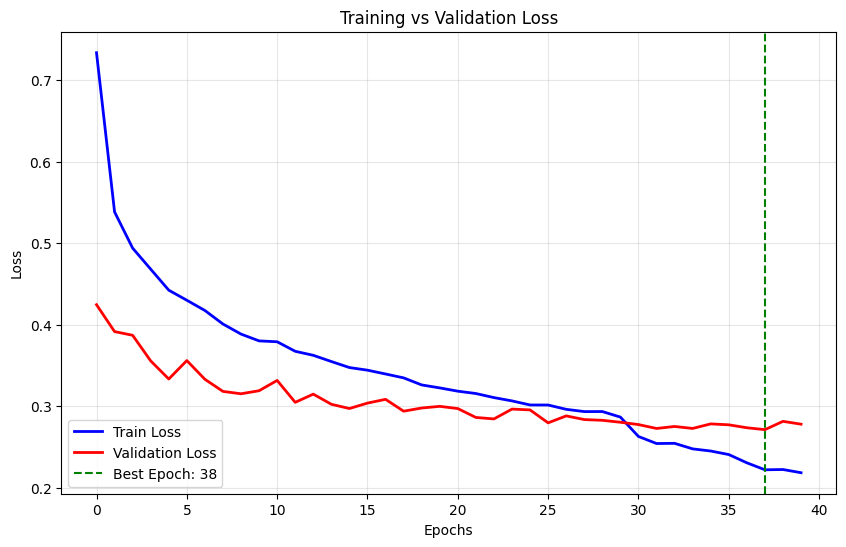

In [37]:
def plot_loss(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    plt.plot(val_losses, label='Validation Loss', color='red', linewidth=2)

    min_val_loss = min(val_losses)
    min_idx = val_losses.index(min_val_loss)
    plt.axvline(x=min_idx, color='green', linestyle='--', label=f'Best Epoch: {min_idx+1}')

    plt.title('Training vs Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
plot_loss(train_losses, val_losses)

# Evaluation

In [38]:
Accuracy = test(model , test_batches ,device)
print(f"Test Accuracy is {Accuracy}")

Test Accuracy is 0.8984872698783875


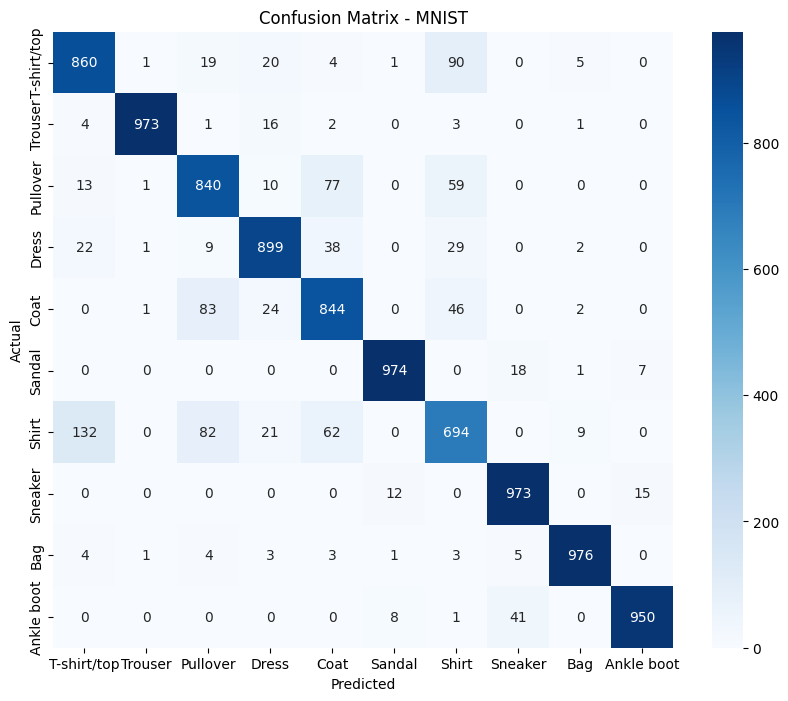

--------------------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.83      0.86      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.81      0.84      0.82      1000
       Dress       0.91      0.90      0.90      1000
        Coat       0.82      0.84      0.83      1000
      Sandal       0.98      0.97      0.98      1000
       Shirt       0.75      0.69      0.72      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.98      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

Per-Class Accuracy:
T-shirt/top: 86.00%
Trouser: 97.30%
Pullover: 84.00%
Dress: 89.90%
Coat: 84.40%
Sandal: 97.40%
Shirt: 69.40%
Sneaker:

In [39]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            labels = torch.argmax(labels, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    classes = data.classes
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - MNIST")
    plt.show()

    print("--"*40)
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=classes))
    class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print("Per-Class Accuracy:")
    for idx, acc in enumerate(class_accuracy):
        print(f"{classes[idx]}: {acc*100:.2f}%")
    overall_acc = np.sum(cm.diagonal()) / np.sum(cm)
    print(f"Overall Accuracy: {overall_acc*100:.2f}%")

evaluate_model(model, test_batches, device)